# AI Engineer Roadmap
## AI Deployment & Productionization
### https://zazencodes.com/courses/ai-engineer-roadmap#ai-deployment-productionization

## Figures

The code below was used to generate plots to include as figures in the lessons.

In [1]:

import matplotlib.pyplot as plt

# Dracula theme colors
BG_COLOR = '#282a36'  # Dark background
FG_COLOR = '#f8f8f2'  # Light foreground text
PURPLE   = '#BD93F9'  # Primary color
ORANGE   = '#FFB86C'  # Secondary color
PINK     = '#FF79C6'  # Tertiary color
GREEN    = '#50FA7B'  # Additional color
CYAN     = '#8BE9FD'  # Additional color

plt.rcParams.update(
    {
        "figure.facecolor": BG_COLOR,
        "axes.facecolor"  : BG_COLOR,
        "axes.edgecolor"  : FG_COLOR,
        "axes.labelcolor" : FG_COLOR,
        "xtick.color"     : FG_COLOR,
        "ytick.color"     : FG_COLOR,
        "text.color"      : FG_COLOR,
        "axes.prop_cycle" : plt.cycler(color=[PURPLE, ORANGE, PINK, CYAN, GREEN]),
        "grid.color"      : FG_COLOR,
        "grid.alpha"      : 0.3,
        "grid.linestyle"  : "--",
    }
)

def style_axes(ax, edgecolor=FG_COLOR, linewidth=1.2):
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors=FG_COLOR)
    for spine in ax.spines.values():
        spine.set_color(FG_COLOR)
    for patch in ax.patches:
        if hasattr(patch, "get_facecolor"):
            face = patch.get_facecolor()
            patch.set_edgecolor(edgecolor or face)
            patch.set_linewidth(linewidth)



In [9]:
0.55*np.sin(2*math.pi*(minutes_of_day-  8*60)/(24*60))

Index([-0.47631397208144133,  -0.4775093479690283,  -0.4786956327669449,
       -0.47987280389003845, -0.48104083892666777, -0.48219971563912933,
         -0.483349411964081,  -0.4844899060129621, -0.48562117607240995,
        -0.4867432006046731,
       ...
        -0.4638652951970871,  -0.4651503019371854,  -0.4664264528860343,
        -0.4676937237475595, -0.46895209039475083,  -0.4702015288701207,
        -0.4714420153861617, -0.47267352632579906,  -0.4738960382428392,
        -0.4751095278624176],
      dtype='float64', length=2880)

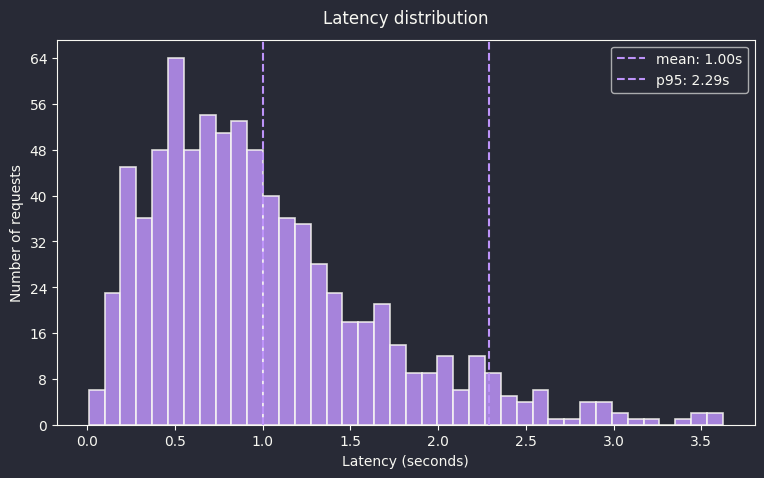

In [13]:
# --- Latency Histogram -----------------------------------------------
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ── dummy latency data (seconds) ──────────────────────────────────────
np.random.seed(42)
latencies = np.random.gamma(shape=2.2, scale=0.45, size=800)
lat_df = pd.DataFrame({"latency_s": latencies})

# ── plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9,5))
bins = "auto" if len(lat_df) > 1500 else 40
ax.hist(lat_df["latency_s"], bins=bins, edgecolor=FG_COLOR, alpha=0.85)

# add mean / p95 markers
mean_lat  = lat_df["latency_s"].mean()
p95_lat   = lat_df["latency_s"].quantile(0.95)
for val, lbl in [(mean_lat, "mean"), (p95_lat, "p95")]:
    ax.axvline(val, linestyle="--", linewidth=1.5, label=f"{lbl}: {val:0.2f}s")

ax.set_title("Latency distribution", pad=12)
ax.set_xlabel("Latency (seconds)")
ax.set_ylabel("Number of requests")
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend()
style_axes(ax)
plt.show()


/var/folders/ll/6ymmghv964ddzxgzk0g867_w0000gn/T/ipykernel_5321/1500232581.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  rng  = pd.date_range("2025-07-07", periods=5*24*60, freq="T")


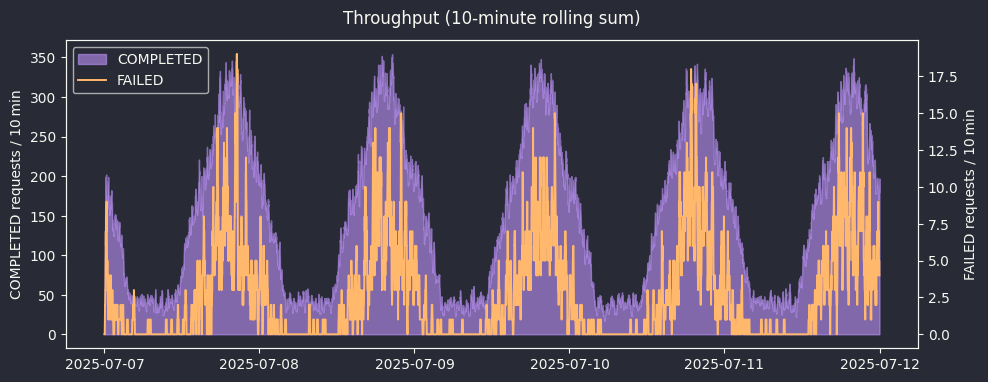

In [36]:
# --- Throughput: COMPLETED vs FAILED (dual‑axis) ---------------------
import numpy as np, pandas as pd, matplotlib.pyplot as plt, math

# ▸ 5 work‑days at 1‑minute resolution
rng  = pd.date_range("2025-07-07", periods=5*24*60, freq="T")
mins = (rng.hour * 60 + rng.minute).to_numpy()

# ▸ Traffic peaks at 11 am & 4 pm
diurnal = (
    np.clip(np.sin((mins - 11*60) / 720 * math.pi), 0, None) +
    np.clip(np.sin((mins - 16*60) / 720 * math.pi), 0, None)
)

λ_started = 4 + 18 * diurnal                        # Poisson mean
started   = np.random.poisson(λ_started)

# ▸ Failure rate rises modestly with load
fail_rate = 0.003 + 0.022 * (diurnal / diurnal.max())   # 0.3 % → 2.5 %
failed    = np.random.binomial(started, p=fail_rate)
completed = started - failed

df = pd.DataFrame({"COMPLETED": completed, "FAILED": failed}, index=rng)

# ▸ 10‑minute rolling sum for smoother curves
roll = df.rolling(10, min_periods=1).sum()

# ── plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11,4))
ax2 = ax.twinx()

# Completed requests (primary y‑axis)
ax.fill_between(roll.index,
                roll["COMPLETED"],
                color=PURPLE, alpha=0.6, label="COMPLETED")

# Failed requests (secondary y‑axis)
ax2.plot(roll.index,
         roll["FAILED"],
         color=ORANGE, linewidth=1.4, label="FAILED")

# Titles & labels
ax.set_title("Throughput (10‑minute rolling sum)", pad=12)
ax.set_ylabel("COMPLETED requests / 10 min")
ax2.set_ylabel("FAILED requests / 10 min")

# Legends (merge handles from both axes)
handles, labels = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(handles + h2, labels + l2, loc="upper left")

# Dracula styling
style_axes(ax)
style_axes(ax2, edgecolor=None)          # second axis: no extra box

plt.show()


/var/folders/ll/6ymmghv964ddzxgzk0g867_w0000gn/T/ipykernel_5321/184169645.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  rng = pd.date_range("2025-07-09 09:00:00", periods=2*60*60, freq="S")


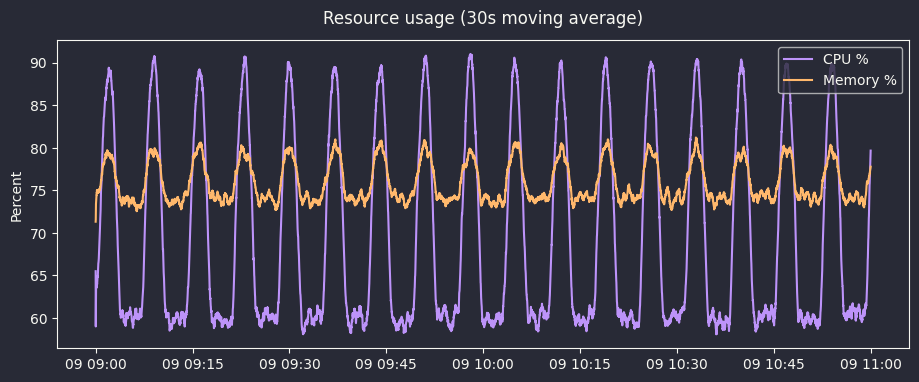

In [26]:
# --- Resource Usage Trend (synthetic, tested) ------------------------
import numpy as np, pandas as pd, matplotlib.pyplot as plt, math

# 2 hours, second‑by‑second
rng = pd.date_range("2025-07-09 09:00:00", periods=2*60*60, freq="S")
sec = np.arange(len(rng))

# pressure oscillates every 7 minutes
pressure = 0.4 + 0.6 * np.clip(np.sin(2 * np.pi * sec / (7*60)), 0, None)

cpu = np.random.normal(loc=40 + 50 * pressure, scale=4).clip(0, 100)
mem = np.random.normal(loc=70 + 10 * pressure, scale=2.5).clip(0, 100)
usage = pd.DataFrame({"cpu": cpu, "mem": mem}, index=rng)

# 30‑sec moving average
roll = usage.rolling("30s", min_periods=1).mean()

fig, ax = plt.subplots(figsize=(11,4))
ax.plot(roll.index, roll["cpu"], label="CPU %")
ax.plot(roll.index, roll["mem"], label="Memory %")
ax.set_title("Resource usage (30s moving average)", pad=12)
ax.set_ylabel("Percent")
ax.legend()
style_axes(ax)
plt.show()


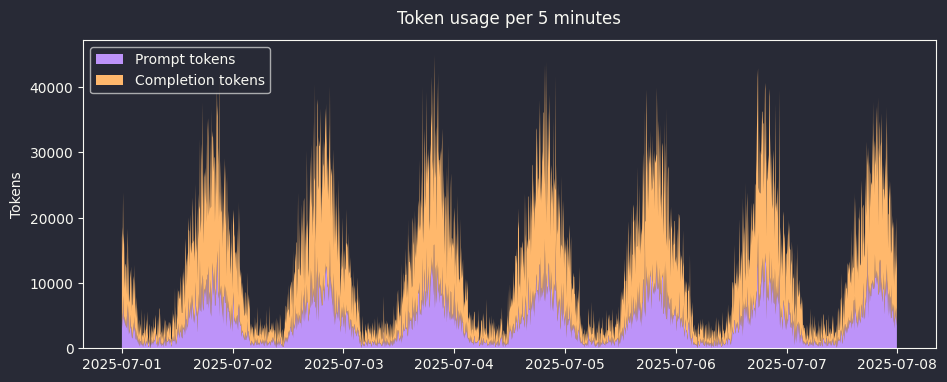

In [32]:
# --- Token Breakdown (synthetic twin‑peak diurnal) -------------------
import numpy as np, pandas as pd, matplotlib.pyplot as plt, math

# ▸ 7 days, 5‑minute resolution
rng  = pd.date_range("2025-07-01", periods=7*24*12, freq="5min")
mins = (rng.hour * 60 + rng.minute).to_numpy()      # minutes since midnight

# ▸ Diurnal load: two peaks per day (≈11:00 & ≈16:00)
cycle = (
    np.clip(np.sin((mins - 11*60) / 720 * math.pi), 0, None) +
    np.clip(np.sin((mins - 16*60) / 720 * math.pi), 0, None)
)

# ▸ Requests per 5‑min bin (Poisson with cycle)
reqs = np.random.poisson(lam=5 + 20 * cycle)        # baseline 5, peak ~25

# ▸ Per‑request token sizes vary slightly with load
prompt_mu     = 180 + 60 * cycle                    # 180 → 240 tokens
completion_mu = 400 + 90 * cycle                    # 400 → 490 tokens

prompt_tok     = np.random.normal(prompt_mu,     50).clip(40)
completion_tok = np.random.normal(completion_mu, 80).clip(40)

agg = pd.DataFrame({
    "prompt_tokens":     (prompt_tok     * reqs).astype(int),
    "completion_tokens": (completion_tok * reqs).astype(int)
}, index=rng)

# ▸ Plot ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11,4))
ax.stackplot(agg.index,
             agg["prompt_tokens"], agg["completion_tokens"],
             labels=["Prompt tokens", "Completion tokens"])
ax.set_title("Token usage per 5 minutes", pad=12)
ax.set_ylabel("Tokens")
ax.legend(loc="upper left")
style_axes(ax)
plt.show()
